# Ejemplo del Avance — Ciencia de Datos (opción alternativa)
**Curso:** Ciencia de Datos  

---

## Descripción del Proyecto
En esta fase inicial, realizarás un análisis profundo sobre los factores que influyen en el desempeño académico de los estudiantes en sus exámenes. Utilizaremos el dataset **"Students Performance in Exams"** (en lugar del dataset original que ustedes si tienen que hacer), que incluye variables demográficas y puntuaciones en áreas clave: Matemáticas, Lectura y Escritura.

Llevarás a cabo un **Análisis Exploratorio de Datos (EDA)** para familiarizarte con la estructura de la información, limpiar los datos si es necesario y descubrir patrones iniciales o anomalías. Este paso es el pilar para cualquier análisis predictivo posterior.

## Objetivo
Realizar un análisis exploratorio para comprender las características fundamentales, tendencias y patrones de los datos relacionados con el desempeño escolar de los alumnos. OJO: Este es un ejemplo con un dtaset conocido para tomarlo como ejemplo.

---

## Instrucciones de la Fase
1. **Carga de Datos:** Importar el dataset y las librerías necesarias.
2. **Análisis Descriptivo:** Calcular estadísticas clave e identificar variables de impacto.
3. **Visualización:** Generar gráficos que expliquen la distribución y relación de las variables.
4. **Interpretación:** Documentar hallazgos.

In [8]:
# ==========================================
# PARTE 1: Carga de Datos y Librerías
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para visualizaciones
sns.set_theme(style="whitegrid")

# Carga del dataset (Asegúrate de tener el archivo 'StudentsPerformance.csv' en tu entorno)
# Dataset link: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
try:
    df = pd.read_csv('StudentsPerformance.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo .csv. Por favor, cárgalo en el entorno.")

# Visualización rápida de los datos
df.head()

Dataset cargado exitosamente.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Análisis Descriptivo
El análisis descriptivo nos permite resumir las características de un conjunto de datos. En este caso, buscaremos entender:
* **Medidas de tendencia central:** Media, mediana y moda de los puntajes.
* **Medidas de dispersión:** Desviación estándar y rangos.
* **Identificación de variables clave:** Determinar qué factores (género, nivel educativo de los padres, preparación) podrían tener mayor correlación con los resultados finales.

In [9]:
# ==========================================
# PARTE 2: Análisis Exploratorio (Estadística)
# ==========================================

# 1. Información general del dataset (tipos de datos y nulos)
print("--- Información del Dataset ---")
print(df.info())

# 2. Estadísticas descriptivas de variables numéricas
print("\n--- Estadísticas Univariadas ---")
display(df.describe())

# 3. Identificación de variables categóricas clave
print("\n--- Conteo de categorías en variables clave ---")
print(df['parental level of education'].value_counts())

# 4. Cálculo de promedio total de los tres exámenes
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

print("\nPrimeras filas con el promedio calculado:")
df.head()

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB
None

--- Estadísticas Univariadas ---


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



--- Conteo de categorías en variables clave ---
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Primeras filas con el promedio calculado:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


### Visualización de Datos
La visualización es la herramienta más poderosa del EDA. Utilizaremos:
1.  **Histogramas:** Para observar la distribución de frecuencia de los puntajes.
2.  **Box Plots (Diagramas de caja):** Para identificar valores atípicos (outliers) y comparar el desempeño entre grupos (ej. por género).
3.  **Scatter Plots (Dispersión):** Para ver la relación entre dos tipos de exámenes (ej. si quien sale bien en lectura, sale bien en escritura).
4.  **Heatmap (Mapa de calor):** Para visualizar la correlación numérica entre las variables.

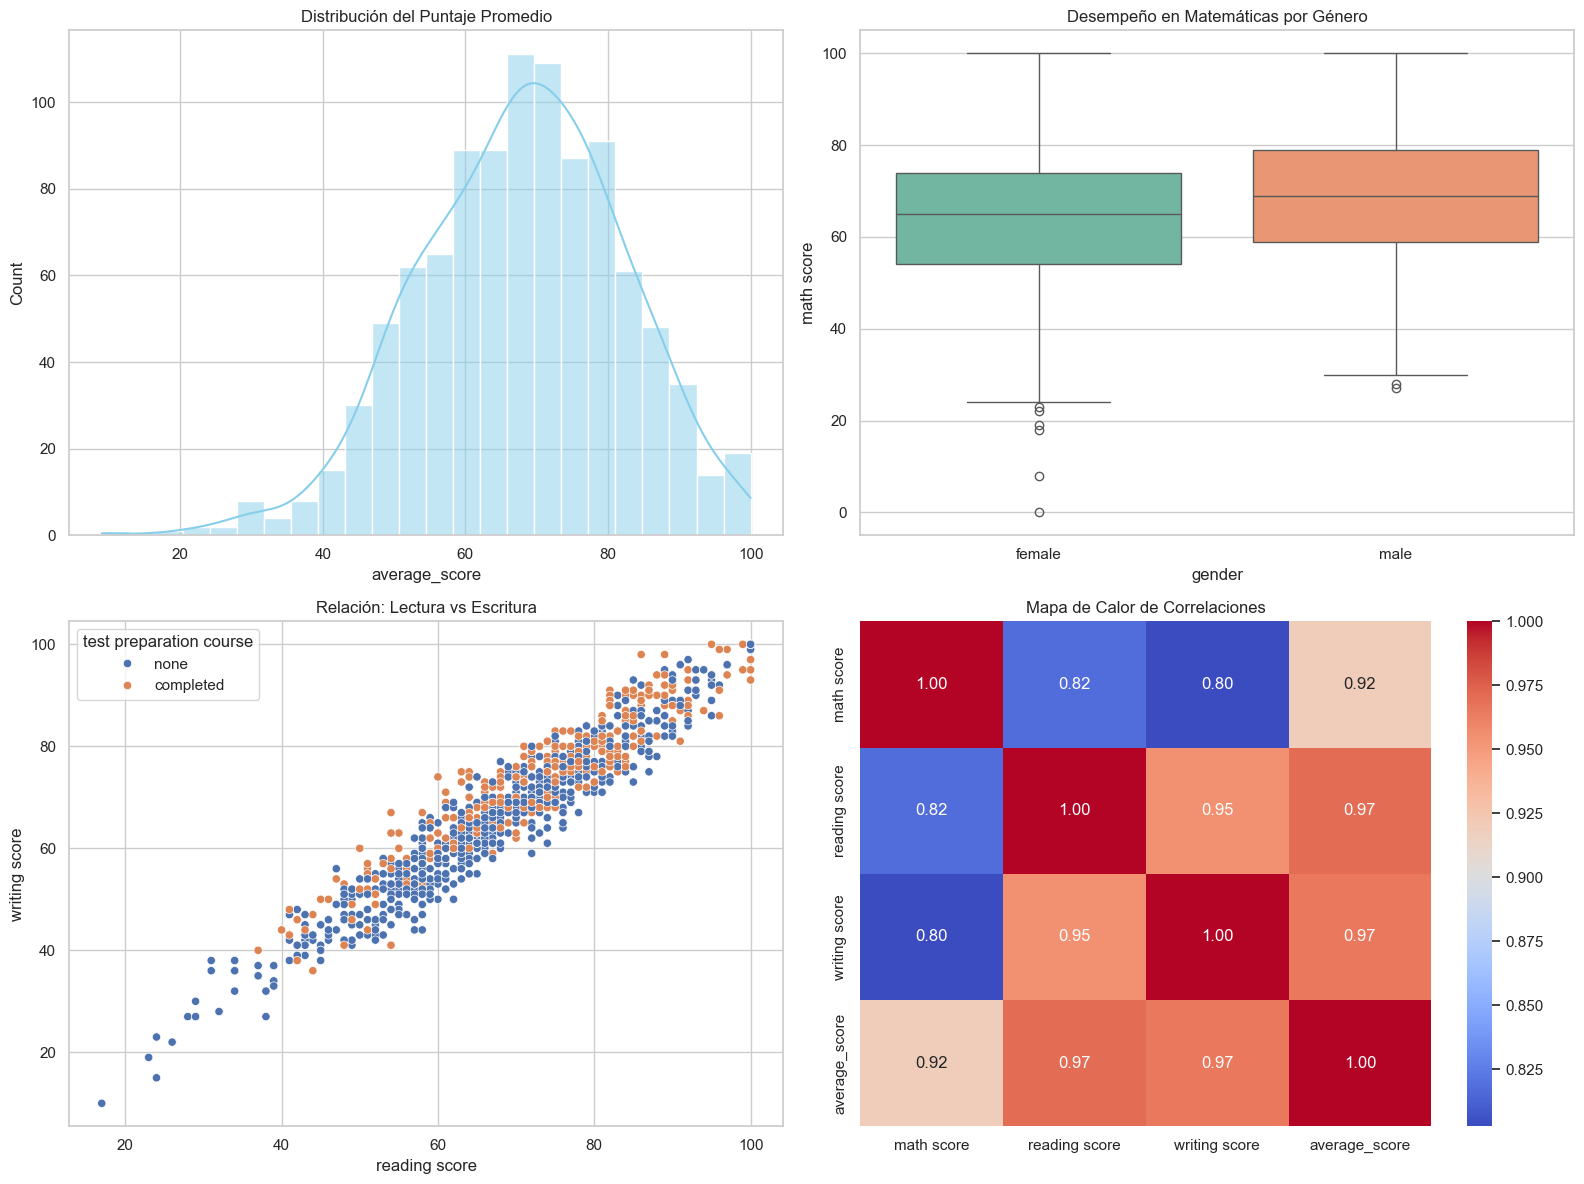

In [15]:
# ==========================================
# PARTE 3: Visualización de Datos
# ==========================================
import warnings
warnings.filterwarnings('ignore')

# Crear una figura con múltiples subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograma: Distribución del puntaje promedio
sns.histplot(df['average_score'], kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución del Puntaje Promedio')

# 2. Box Plot: Puntaje de matemáticas por género
sns.boxplot(x='gender', y='math score', data=df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Desempeño en Matemáticas por Género')

# 3. Scatter Plot: Relación entre Lectura y Escritura
sns.scatterplot(x='reading score', y='writing score', hue='test preparation course', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Relación: Lectura vs Escritura')

# 4. Mapa de Calor: Correlaciones
# Solo tomamos columnas numéricas
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Mapa de Calor de Correlaciones')

plt.tight_layout()
plt.show()

## Hallazgos e Interpretación

Tras realizar el análisis exploratorio, se pueden documentar las siguientes observaciones iniciales:

1.  **Correlación Alta:** Existe una correlación muy fuerte entre los puntajes de **Lectura (Reading)** y **Escritura (Writing)**. Esto sugiere que los estudiantes con habilidades lingüísticas sólidas tienden a desempeñarse bien en ambas áreas simultáneamente.
2.  **Influencia del Curso de Preparación:** (Basado en el scatter plot) Los estudiantes que completaron el curso de preparación tienden a agruparse en las zonas de puntajes más altos.
3.  **Distribución de Puntajes:** La mayoría de los estudiantes se encuentran en un rango de 60 a 80 puntos. Existen pocos casos de excelencia absoluta (100) y también algunos valores atípicos en la parte baja de la escala (outliers detectados en los box plots).
4.  **Variables Críticas:** El "nivel educativo de los padres" y el "curso de preparación" parecen ser factores determinantes que ameritan un análisis estadístico más profundo (como pruebas de hipótesis) en la siguiente fase del proyecto.

---
### Entregables para GitHub:
Este notebook debe guardarse en la ruta correspondiente a la semana en su repositorio

# Siguientes pasos (No hacer)

Este tipo de análisis se realizarán más adelante, solo es un ejemplo de como se hace.

1. ¿Afecta el test preparation course? (Comparación Binaria)
    
    Dado que esta variable solo tiene dos opciones (none o completed), la mejor forma de analizarla es comparar los promedios de ambos grupos.
    - Técnica visual: Box Plots (Diagramas de caja). Permiten ver no solo el promedio, sino la dispersión y si los "preparados" tienen un piso más alto de calificación.
    - Técnica estadística: Prueba t de Student. Sirve para determinar si la diferencia entre las medias de los dos grupos es estadísticamente significativa o si se debe al azar.

2. ¿Influye el parental level of education? (Comparación Multinivel)
    
    Aquí tenemos múltiples categorías (desde high school hasta master's degree). Queremos ver si existe una tendencia ascendente: a mayor estudio de los padres, ¿mejor desempeño del hijo?
    - Técnica visual: Bar Plot de Promedios con Intervalos de Confianza. Esto muestra la media de cada grupo y una pequeña línea que indica la incertidumbre estadística.
    - Técnica estadística: ANOVA de un factor. Se utiliza para comparar las medias de tres o más grupos. La hipótesis nula ($H_0$) es que todas las medias son iguales:
    
    $$\mu_1 = \mu_2 = \dots = \mu_k$$
    
    Si el valor $p < 0.05$, rechazamos $H_0$ y confirmamos que el nivel educativo sí influye.

3. ¿Afecta la race/ethnicity?
    
    Este análisis es similar al anterior, ya que la etnia está categorizada en grupos (Group A, B, C, etc.).

    - Técnica visual: Violin Plots. Son excelentes aquí porque muestran la densidad de los puntajes. Puedes ver si un grupo étnico tiene una distribución más "estirada" (más desigualdad interna) o más compacta.

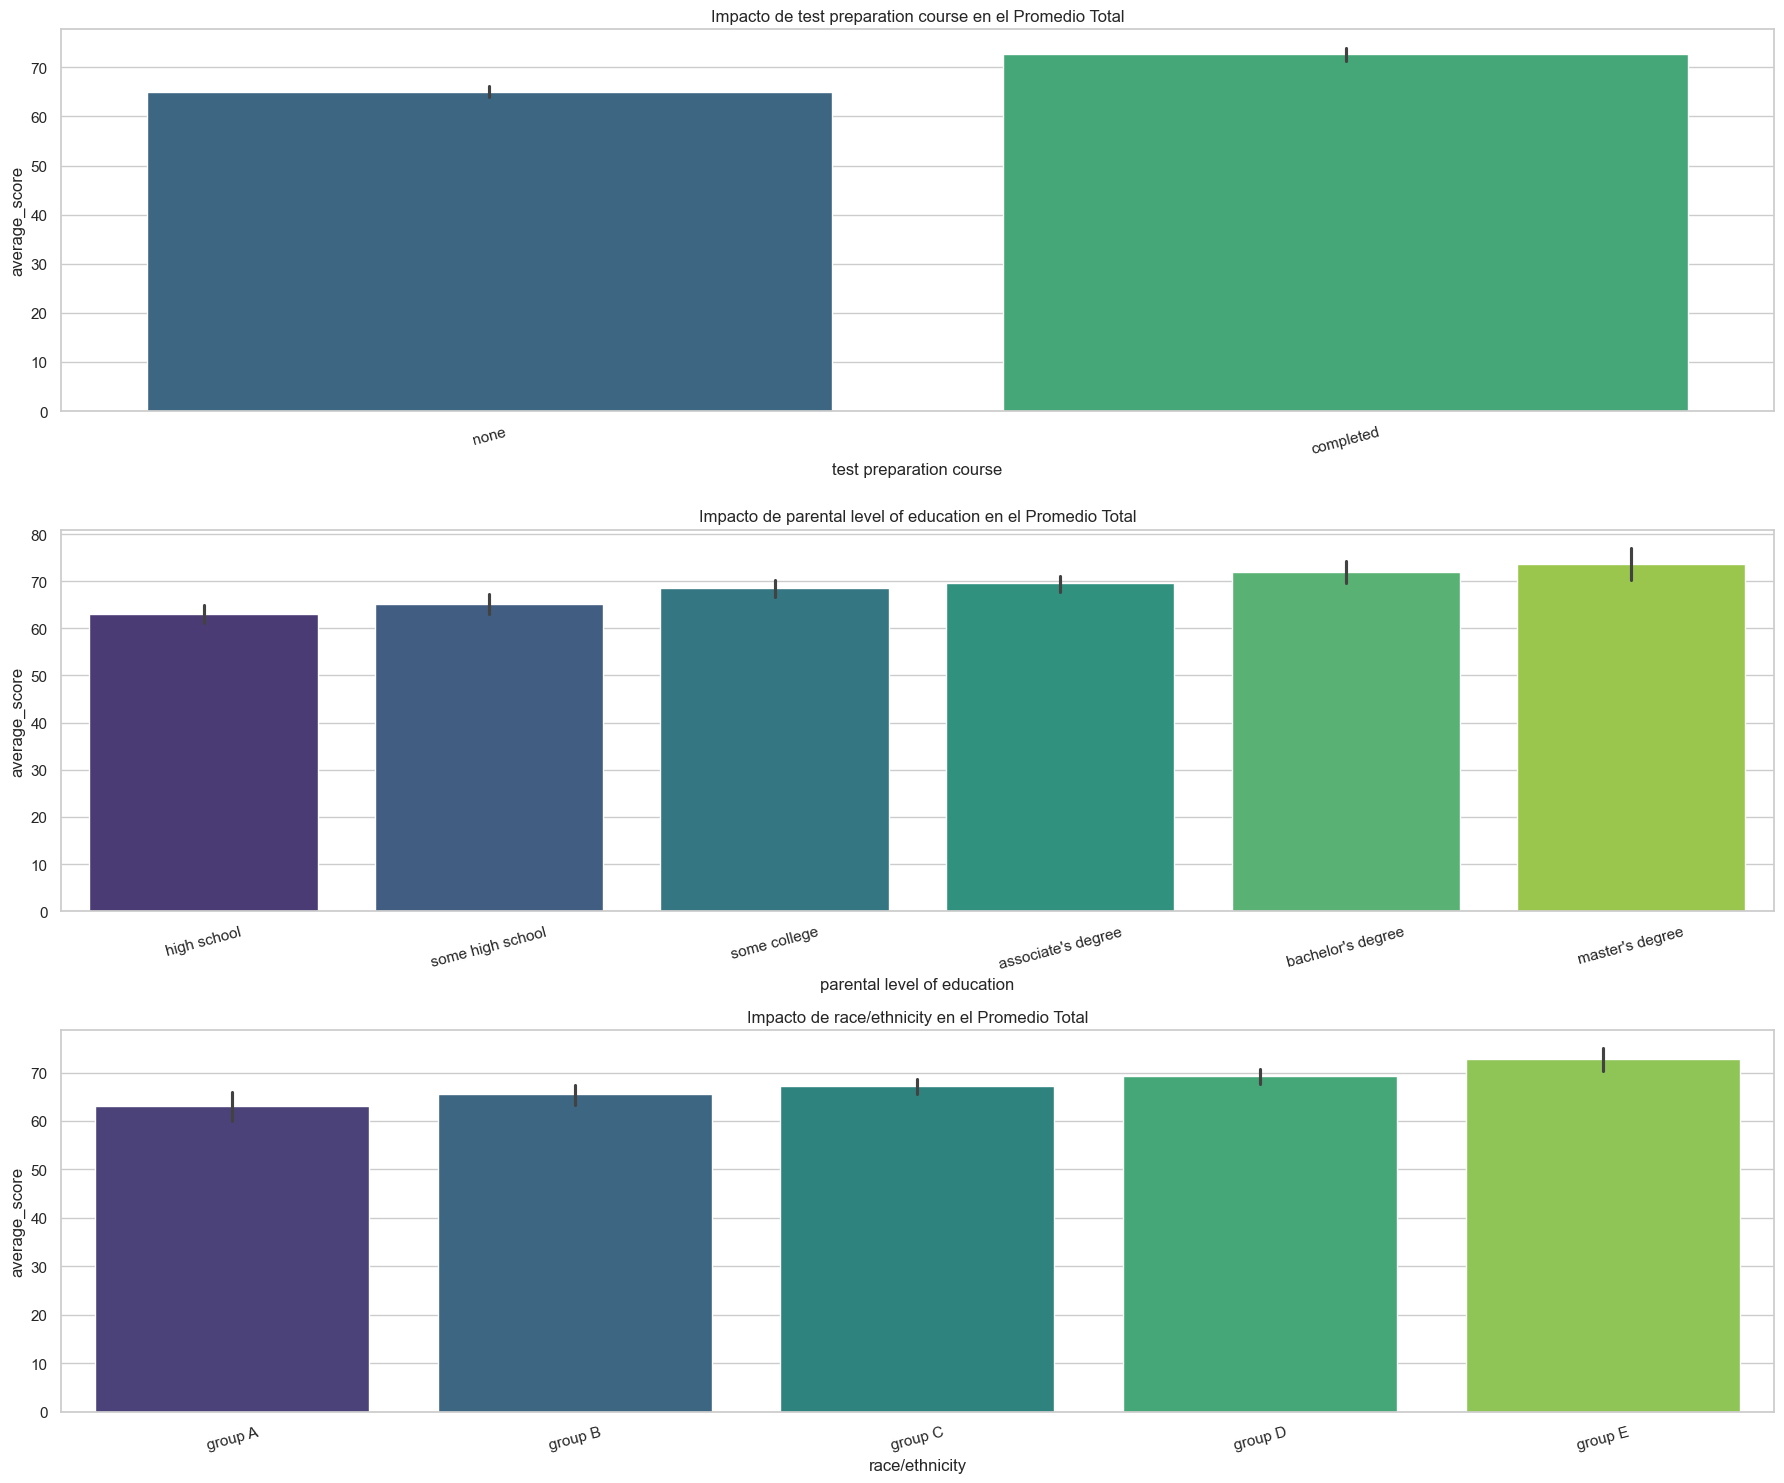

Resultado ANOVA para Educación Parental: F-statistic = 10.7531, p-value = 4.3810e-10


In [14]:
# ==========================================
# ANÁLISIS DE DEPENDENCIAS
# ==========================================
import warnings
warnings.filterwarnings('ignore')

variables_a_comparar = ['test preparation course', 'parental level of education', 'race/ethnicity']

plt.figure(figsize=(18, 15))

for i, var in enumerate(variables_a_comparar):
    plt.subplot(3, 1, i+1)
    # Ordenar por puntaje promedio para facilitar la lectura visual
    orden = df.groupby(var)['average_score'].mean().sort_values().index
    
    sns.barplot(x=var, y='average_score', data=df, order=orden, palette='viridis')
    plt.title(f'Impacto de {var} en el Promedio Total')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Ejemplo de ANOVA rápido para el nivel educativo de los padres
import scipy.stats as stats

grupos = [df[df['parental level of education'] == nivel]['average_score'] 
          for nivel in df['parental level of education'].unique()]

f_stat, p_val = stats.f_oneway(*grupos)
print(f"Resultado ANOVA para Educación Parental: F-statistic = {f_stat:.4f}, p-value = {p_val:.4e}")

¿Qué significan los resultados?

- Si el p-value es menor a 0.05: Puedes afirmar con un 95% de confianza que esa variable (como la educación de los padres) sí tiene un efecto real en las calificaciones.

- Si el p-value es mayor a 0.05: La diferencia que ves en las gráficas podría ser simple ruido estadístico y no una dependencia real.